# Necessary code to run

In [1]:
# Extract, transform, load.
import yfinance as yf
import pandas as pd


# -------EXTRACT----

# Dow 30 composition in 2003
dow_2003 = [
    "MMM", "AA", "MO", "AXP", "T",
    "BA", "CAT", "C", "KO", "DD", 
    "EK", "XOM", "GE", "GM", "HPQ", 
    "HD", "HON", "INTC", "IBM", "IP", 
    "JNJ", "JPM", "MCD", "MRK", "MSFT", 
    "PG", "SBC", "UTX", "WMT", "DIS"
]

def get_dow_forward_history():
    # Historical changes from 2003 to present
    forward_steps = {
        2004: {"remove": ["T", "EK", "IP"], "add": ["AIG", "PFE", "VZ"]},
        2005: {"remove": ["SBC"], "add": ["T"]},
        2008: {"remove": ["AIG", "MO", "HON"], "add": ["KFT", "CVX", "BAC"]},
        2009: {"remove": ["GM", "C"], "add": ["TRV", "CSCO"]},
        2012: {"remove": ["KFT"], "add": ["UNH"]},
        2013: {"remove": ["AA", "BAC", "HPQ"], "add": ["GS", "NKE", "V"]},
        2015: {"remove": ["T"], "add": ["AAPL"]},
        2017: {"remove": ["DD"], "add": ["DWDP"]},
        2018: {"remove": ["GE"], "add": ["WBA"]},
        2019: {"remove": ["DWDP"], "add": ["DOW"]},
        2020: {"remove": ["XOM", "PFE", "UTX"], "add": ["AMGN", "HON", "CRM"]},
        2024: {"remove": ["INTC", "DOW", "WBA"], "add": ["NVDA", "SHW", "AMZN"]},
    }

    history = {}
    temp_list = list(dow_2003)
    history[2003] = sorted(list(temp_list))
    
    for year in range(2004, 2027):
        if year in forward_steps:
            for ticker in forward_steps[year]["remove"]:
                if ticker in temp_list:
                    temp_list.remove(ticker)
            for ticker in forward_steps[year]["add"]:
                temp_list.append(ticker)
        
        history[year] = sorted(list(temp_list))
    
    return history



dow_history = get_dow_forward_history()

In [2]:
all_tickers = set()
    
    # Step 1: Combine all tickers from all years
for year, tickers in dow_history.items():
        # update() adds elements from tickers list to the set
    all_tickers.update(tickers)
    
    # Step 2: Remove duplicates explicitly (set already does this)
unique_tickers = set(all_tickers)
    
    # Step 3: Convert to sorted list for output
sorted(list(unique_tickers))

['AA',
 'AAPL',
 'AIG',
 'AMGN',
 'AMZN',
 'AXP',
 'BA',
 'BAC',
 'C',
 'CAT',
 'CRM',
 'CSCO',
 'CVX',
 'DD',
 'DIS',
 'DOW',
 'DWDP',
 'EK',
 'GE',
 'GM',
 'GS',
 'HD',
 'HON',
 'HPQ',
 'IBM',
 'INTC',
 'IP',
 'JNJ',
 'JPM',
 'KFT',
 'KO',
 'MCD',
 'MMM',
 'MO',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PFE',
 'PG',
 'SBC',
 'SHW',
 'T',
 'TRV',
 'UNH',
 'UTX',
 'V',
 'VZ',
 'WBA',
 'WMT',
 'XOM']

In [3]:
# Monthly prices since 2006 until 2023 (20 years) 
#Monthly_prices = yf.download(unique_tickers, start="2006-01-01", end="2026-12-31",interval='1mo')["Close"]

In [4]:
# save to csv. first test data.Need to fix problems 1
#Monthly_prices.to_csv("dow_monthly_prices.csv")

In [5]:
#Daily_prices.to_csv("dow_daily_prices.csv")

In [6]:
#Load monthly prices from csv
import pandas as pd
import numpy as np

monthly_prices_loaded = pd.read_csv("dow_monthly_prices.csv", index_col=0, parse_dates=True)
daily_prices_loaded= pd.read_csv("dow_daily_prices.csv", index_col=0, parse_dates=True)


In [7]:
# Data cleanning
# Drop na
Monthly_prices=monthly_prices_loaded
Daily_prices=daily_prices_loaded


In [8]:
Monthly_prices.dropna(axis=1, inplace=True)  # Drops columns (tickers) with any NaN, KFT, SBC, UTX,V,WBA,DOW,DWDP,EK,GM

In [9]:
Monthly_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 243 entries, 2006-01-01 to 2026-03-01
Data columns (total 42 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      243 non-null    float64
 1   AAPL    243 non-null    float64
 2   AIG     243 non-null    float64
 3   AMGN    243 non-null    float64
 4   AMZN    243 non-null    float64
 5   AXP     243 non-null    float64
 6   BA      243 non-null    float64
 7   BAC     243 non-null    float64
 8   C       243 non-null    float64
 9   CAT     243 non-null    float64
 10  CRM     243 non-null    float64
 11  CSCO    243 non-null    float64
 12  CVX     243 non-null    float64
 13  DD      243 non-null    float64
 14  DIS     243 non-null    float64
 15  GE      243 non-null    float64
 16  GS      243 non-null    float64
 17  HD      243 non-null    float64
 18  HON     243 non-null    float64
 19  HPQ     243 non-null    float64
 20  IBM     243 non-null    float64
 21  INTC    243 non-null

In [10]:
Daily_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5582 entries, 2004-01-02 to 2026-03-11
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      5582 non-null   float64
 1   AAPL    5582 non-null   float64
 2   AIG     5582 non-null   float64
 3   AMGN    5582 non-null   float64
 4   AMZN    5582 non-null   float64
 5   AXP     5582 non-null   float64
 6   BA      5582 non-null   float64
 7   BAC     5582 non-null   float64
 8   C       5582 non-null   float64
 9   CAT     5582 non-null   float64
 10  CRM     5464 non-null   float64
 11  CSCO    5582 non-null   float64
 12  CVX     5582 non-null   float64
 13  DD      5582 non-null   float64
 14  DIS     5582 non-null   float64
 15  DOW     1754 non-null   float64
 16  DWDP    0 non-null      float64
 17  EK      0 non-null      float64
 18  GE      5582 non-null   float64
 19  GM      3849 non-null   float64
 20  GS      5582 non-null   float64
 21  HD      5582 non-nu

In [11]:
Daily_prices.dropna(axis=1, inplace=True) # Drops columns (tickers) with any NaN, KFT, SBC, UTX,V,WBA,DOW,DWDP,EK,GM

# Full function of optimization book

In [8]:
from typing import Dict, Tuple, Callable
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier


# Full claude code


def backtest(
    portfolio_funcs: Dict[str, Callable],
    prices: pd.DataFrame,
    lookback: int,
    rebalance_every: int = 1,
    optimize_every: int = 1,
    cost_bps: float = 0,
    verbose: bool = True
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Walk-forward backtester for multiple portfolio strategies.
    
    Args:
        portfolio_funcs: Dict of {strategy_name: optimization_function}
        prices: DataFrame with asset prices (index=dates, columns=tickers)
        lookback: Training window size (in periods)
        rebalance_every: Rebalance frequency (in periods)
        optimize_every: Reoptimization frequency (in periods)
        cost_bps: Transaction costs in basis points
        verbose: Print progress
    
    Returns:
        Tuple of (portfolio_returns_df, weights_dict)
    """
    N = prices.shape[1]
    X = prices.pct_change().dropna()
    T = len(X)
    
    portf_rets = {}
    ws = {}

    for portfolio_name, portfolio_func in portfolio_funcs.items():
        if verbose:
            print(f"Backtesting portfolio: {portfolio_name}...")
            print(f"  Total periods: {T}, Lookback: {lookback}, OOS periods: {T - lookback}\n")

        # Initialize variables
        current_w = np.ones(N) / N  # Start with equal weight
        w = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
        portf_ret = pd.Series(index=X.index, dtype=float)
        portf_ret.name = portfolio_name

        for t in range(lookback, T):
            # Reoptimize portfolio if necessary
            if (t - lookback) % optimize_every == 0:
                try:
                    train_data = X.iloc[t - lookback : t]
                    new_w = portfolio_func(train_data)
                    turnover = np.abs(new_w - current_w).sum()
                    transaction_cost = turnover * cost_bps / 1e4
                    current_w = new_w
                    
                    if verbose and (t - lookback) % (optimize_every * 6) == 0:
                        print(f"  t={t} ({X.index[t].date()}): Reoptimized, Turnover={turnover:.2%}")
                        
                except Exception as e:
                    if verbose:
                        print(f"  ✗ Optimization failed at t={t}: {e}")
                    transaction_cost = 0

            # Store weights
            w.iloc[t] = current_w

            # Calculate portfolio return for this period (before rebalancing)
            period_return = (X.iloc[t] * current_w).sum()
            portf_ret.iloc[t] = period_return - transaction_cost

            # Update weights based on asset performance (drift)
            current_w = current_w * (1 + X.iloc[t])
            current_w = current_w / current_w.sum()

        # Keep a record (remove initial NaNs)
        portf_rets[portfolio_name] = portf_ret[lookback:]
        ws[portfolio_name] = w[lookback:]
        
        if verbose:
            ann_ret = (1 + portf_ret[lookback:]).prod() ** (252 / len(portf_ret[lookback:])) - 1
            ann_vol = portf_ret[lookback:].std() * np.sqrt(252)
            sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
            print(f"  ✓ Complete: Ann.Return={ann_ret:.2%}, Ann.Vol={ann_vol:.2%}, Sharpe={sharpe:.3f}\n")

    # Combine all portfolio returns into a single DataFrame
    portf_rets_df = pd.DataFrame(portf_rets)

    return portf_rets_df, ws


# ── Define optimization functions ────────────────────────────────────────────
def mvo_optimizer(train_returns, risk_free_rate=0.02):
    """Mean-Variance Optimization using max Sharpe ratio"""
    mean_returns = train_returns.mean()
    cov_matrix = train_returns.cov()
    
    ef = EfficientFrontier(mean_returns, cov_matrix, weight_bounds=(0, 1))
    weights = ef.max_sharpe(risk_free_rate=risk_free_rate)
    
    return np.array(list(weights.values()))


def equal_weight_optimizer(train_returns):
    """Equal-weight baseline"""
    N = train_returns.shape[1]
    return np.ones(N) / N


# ── Run backtest ─────────────────────────────────────────────────────────────
# Use daily returns
lookback_days = round(0.5 * len(Daily_prices))  # First 50% as training window
print(f"Daily data: {len(Daily_prices)} trading days")
print(f"Lookback window: {lookback_days} days\n")

portfolio_functions = {
    'MVO_Sharpe': lambda X: mvo_optimizer(X, risk_free_rate=0.02),
    'Equal_Weight': lambda X: equal_weight_optimizer(X),
}

portf_returns_df, weights_dict = backtest(
    portfolio_funcs=portfolio_functions,
    prices=Daily_prices,
    lookback=lookback_days,
    rebalance_every=21,  # Monthly (≈21 trading days)
    optimize_every=63,   # Quarterly (≈63 trading days)
    cost_bps=10,         # 10 basis points per transaction
    verbose=True
)

print("\n" + "="*70)
print(portf_returns_df.describe())

Daily data: 5582 trading days
Lookback window: 2791 days

Backtesting portfolio: MVO_Sharpe...
  Total periods: 5581, Lookback: 2791, OOS periods: 2790

  ✗ Optimization failed at t=2791: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=2854: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=2917: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=2980: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=3043: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=3106: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=3169: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Opt

# Helper functions, optimizers and portfolio metrics

In [ ]:
# Optimizers
from pypfopt import HRPOpt

def max_sharpe(train_returns):
    risk_free_rate = 0.02
    """Mean-Variance Optimization using max Sharpe ratio"""
    cov_matrix = train_returns.cov()

    annualized_return = (1 + train_returns.mean())**252 - 1
    
    # DEBUG: Print statistics
    print(f"\n  [DEBUG] Train returns shape: {train_returns.shape}")
    print(f"  [DEBUG] Annualized return shape:{annualized_return.shape} {annualized_return}")
    print(f"  [DEBUG] Covariance matrix:{cov_matrix.shape} \n{cov_matrix}")

    try:
        ef = EfficientFrontier(annualized_return, cov_matrix)
        weights = ef.max_sharpe(risk_free_rate=risk_free_rate)
        w = np.array(list(weights.values()))
        print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {ef.clean_weights()}")
        return w
    
    except ValueError as e:
        print(f"  [DEBUG] ✗ Optimization failed: {e}")


def equal_weight_optimizer(train_returns):
    """Equal-weight baseline"""
    N = train_returns.shape[1]
    return np.ones(N) / N



def HRP(train_returns) :
    hrp = HRPOpt(train_returns)
    hrp.optimize()
    # The weights are returned as OrderedDict, not ndarray
    weights = hrp.weights
    weights_clean=hrp.clean_weights()
    print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {weights_clean}")

    return weights

def MVO(train_returns): 
    """Mean-Variance Optimization using max Sharpe ratio"""
    cov_matrix = train_returns.cov()

    annualized_return = (1 + train_returns.mean())**252 - 1
    
    # DEBUG: Print statistics
    #print(f"\n  [DEBUG] Train returns shape: {train_returns.shape}")
    #print(f"  [DEBUG] Annualized return: {annualized_return}")
    #print(f"  [DEBUG] Covariance matrix:\n{cov_matrix}")

    try:
        ef = EfficientFrontier(annualized_return, cov_matrix)
        weights = ef.min_volatility()
        w = np.array(list(weights.values()))
        print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {ef.clean_weights()}")
        return w
    
    except ValueError as e:
        print(f"  [DEBUG] ✗ Optimization failed: {e}")

def cp_max_sharpe(train_returns,cp_returns):
    train_returns.index.max()
    last_period = train_returns.index.max().to_period('M')
    #Search last lower bound of cp interval, filtering index to match last monnth
    print(f"CP month: {last_period}")
    cp_returns = cp_returns[cp_returns.index.to_period('M') == last_period]

    #cp_returns drop column CRM
    cp_returns = cp_returns.drop(columns=['CRM'])

    cov_matrix = train_returns.cov()

    annualized_return = (1 + cp_returns.mean())**12 - 1

        # DEBUG: Print statistics
    print(f"\n  [DEBUG] Train returns shape: {train_returns.shape}")
    print(f"  [DEBUG] Annualized return: shape: {annualized_return.shape} {annualized_return}")
    print(f"  [DEBUG] Covariance matrix:{cov_matrix.shape} \n{cov_matrix}")

    try:
        ef = EfficientFrontier(annualized_return, cov_matrix)
        weights = ef.max_sharpe(risk_free_rate=risk_free_rate)

        w = np.array(list(weights.values()))
        print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {ef.clean_weights()}")
        return w
    
    except ValueError as e:
        print(f"  [DEBUG] ✗ Optimization failed: {e}")
    return

"""
def penalty_max_sharpe(train_returns):
        # Placeholder for a custom optimization function that applies penalties
        risk_free_rate = 0.02
        cov_matrix = train_returns.cov()

        annualized_return = (1 + train_returns.mean())**252 - 1
        
        # DEBUG: Print statistics
        print(f"\n  [DEBUG] Train returns shape: {train_returns.shape}")
        #print(f"  [DEBUG] Annualized return: {annualized_return}")
        #print(f"  [DEBUG] Covariance matrix:\n{cov_matrix}")

        try:
            ef = EfficientFrontier(annualized_return, cov_matrix)
            def L1_norm(w, k=1):
                return k * cp.norm(w, 1)

            ef.add_objective(L1_norm, k=2)
            weights = ef.max_sharpe(risk_free_rate=risk_free_rate)

            w = np.array(list(weights.values()))
        # print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {w}")
            return w
        
        except ValueError as e:
            print(f"  [DEBUG] ✗ Optimization failed: {
        return

"""

'\ndef penalty_max_sharpe(train_returns):\n        # Placeholder for a custom optimization function that applies penalties\n        risk_free_rate = 0.02\n        cov_matrix = train_returns.cov()\n\n        annualized_return = (1 + train_returns.mean())**252 - 1\n\n        # DEBUG: Print statistics\n        print(f"\n  [DEBUG] Train returns shape: {train_returns.shape}")\n        #print(f"  [DEBUG] Annualized return: {annualized_return}")\n        #print(f"  [DEBUG] Covariance matrix:\n{cov_matrix}")\n\n        try:\n            ef = EfficientFrontier(annualized_return, cov_matrix)\n            def L1_norm(w, k=1):\n                return k * cp.norm(w, 1)\n\n            ef.add_objective(L1_norm, k=2)\n            weights = ef.max_sharpe(risk_free_rate=risk_free_rate)\n\n            w = np.array(list(weights.values()))\n        # print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {w}")\n            return w\n\n        except ValueError as e:\n            print(f"  [DEBUG] ✗ Opt

In [ ]:
# Portfolio metrics
from typing import Dict

def calculate_performance_metrics(returns: pd.DataFrame) -> Dict[str, float]:
    risk_free_rate_annual = 0.05   # ~5% in 2023-2024 environment
    risk_free_rate_daily  = (1 + risk_free_rate_annual) ** (1/252) - 1
    trading_days = 252    # Number of trading days in a year

    # Calculate Annualized Return
    annualized_return = (1 + returns.mean())**trading_days - 1

    # Calculate Annualized Volatility
    annualized_volatility = returns.std() * np.sqrt(trading_days)

    # Calculate Sharpe Ratio
    sharpe_ratio = (returns.mean() - risk_free_rate_daily) / returns.std()
    sharpe_ratio *= np.sqrt(trading_days)  # Annualize Sharpe ratio

    # Calculate Maximum Drawdown
    def calculate_max_drawdown(returns):
        cumulative_returns = (1 + returns).cumprod()
        running_max = cumulative_returns.cummax()
        drawdown = (cumulative_returns - running_max) / running_max
        max_drawdown = drawdown.min()
        return max_drawdown

    max_drawdown = returns.apply(calculate_max_drawdown)

    return {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

def print_table_performance_metrics(returns: pd.DataFrame):
    performance_table = pd.DataFrame(calculate_performance_metrics(returns))

    # Display the performance table
    performance_table_styled = performance_table.style.format("{:.2f}")
    display(performance_table_styled)

# Adaptation current function, rolling window

In [ ]:
# Match CP intervals: monthly.
#start index + 99
#Daily_prices = Daily_prices.copy().iloc[100:]
# Match with cp intervals, start date 2013-06-01 00:00:00
Daily_prices=Daily_prices[Daily_prices.index >= '2013-06-01 00:00:00'].copy()

In [155]:
Daily_prices

,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-06-03,18.763443,13.794974,33.909637,69.733727,13.344000,64.089943,85.398293,10.592159,38.653412,62.275814,...,0.337092,15.480149,54.147644,55.311630,10.754893,62.890625,50.781376,25.360067,19.724163,54.373047
2013-06-04,18.455114,13.751820,33.417084,68.439323,13.285000,63.746307,84.440361,10.443634,38.110374,62.123978,...,0.337559,15.429950,53.945435,53.923676,10.938901,62.935654,50.425587,25.453884,19.789310,53.974743
2013-06-05,18.058706,13.623271,33.265541,66.547050,13.358500,62.656788,83.490913,10.240237,37.217663,61.039394,...,0.330327,15.329535,53.450397,52.839874,10.813164,61.749332,49.932331,25.172451,19.609505,53.297016
2013-06-06,18.190845,13.419740,33.992985,68.580040,13.391500,63.897179,84.567520,10.326288,37.812801,60.735737,...,0.332426,15.680978,53.561954,53.595882,10.981832,61.749332,50.069778,26.042803,19.708534,53.641815
2013-06-07,18.345003,13.522270,34.311253,69.508598,13.843500,65.405777,86.881752,10.467104,38.385609,61.205715,...,0.337092,15.764653,54.210396,54.118580,10.871428,63.033554,50.595387,26.183517,19.890942,54.367107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-05,60.281277,260.290009,80.070000,367.600006,218.940002,307.209991,222.059998,49.530003,108.949997,706.080017,...,183.339996,26.610001,153.990005,335.450012,28.969999,305.527496,286.542328,51.180000,123.309998,150.759995
2026-03-06,59.552471,257.459991,78.720001,369.529999,213.210007,301.000000,231.110001,48.639999,106.529999,680.900024,...,177.820007,27.049999,153.630005,329.880005,28.639999,305.198669,284.270020,51.119999,123.800003,151.210007
2026-03-09,61.059998,259.880005,77.620003,376.970001,213.490005,305.380005,225.000000,47.900002,106.589996,704.820007,...,182.649994,26.809999,155.220001,333.399994,27.530001,302.089996,285.170013,50.450001,124.339996,150.440002


In [156]:
from typing import Dict, Tuple, Callable
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier

# Current function to updrade

def backtest(
    portfolio_funcs: Dict[str, Callable],
    prices: pd.DataFrame,
    lookback: int,
    optimize_every: int = 1,
    verbose: bool = True
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Walk-forward backtester for multiple portfolio strategies.
    
    Args:
        portfolio_funcs: Dict of {strategy_name: optimization_function}
        prices: DataFrame with asset prices (index=dates, columns=tickers)
        lookback: Training window size (in periods)
        optimize_every: Reoptimization frequency (in periods)
        verbose: Print progress
    
    Returns:
        Tuple of (portfolio_returns_df, weights_dict)
    """
    N = prices.shape[1]
    X = prices.pct_change().dropna()
    T = len(X)
    
    portf_rets = {}
    ws = {}

    for portfolio_name, portfolio_func in portfolio_funcs.items():
        if verbose:
            print(f"Backtesting portfolio: {portfolio_name}...")
            print(f"  Total periods: {T}, Lookback: {lookback}, OOS periods: {T - lookback}\n")

        # Initialize variables
        current_w = np.repeat(0, N)  # Start with zero weight (will be set at first optimization)
        w = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
        portf_ret = pd.Series(index=X.index,  dtype=float)
        portf_ret.name = portfolio_name

        for t in range(lookback, T):
            # Reoptimize portfolio if necessary
            if (t - lookback) % optimize_every == 0:
                    
                    train_data = X.iloc[t - lookback : t]
                    print(f"Reoptimizing lookback at t={t} ({X.index[t].date()})...")
                    # show min date and max date
                    print(f"  [DEBUG] Training data range: {train_data.index[0].date()} to {train_data.index[-1].date()}")
                    #print(f"  [DEBUG] Training data shape: {train_data.shape}")
                    new_w = portfolio_func(train_data)
                    current_w = new_w

            # Store weights
            w.iloc[t] = current_w

            # Calculate portfolio return for this period (before rebalancing)
            Portfolio_period_return = (X.iloc[t] * current_w).sum()
            portf_ret.iloc[t] = Portfolio_period_return  # Store in Series


            # DEBUG: show OOS row time and contributions
            row_date = X.index[t]
            row_contrib = (X.iloc[t] * current_w)
            print(f"[DEBUG] OOS date: {row_date.date()}, return: {Portfolio_period_return:.6f}, n_assets: {len(current_w)}")
            #print(f"[DEBUG] Top contributions:\n{row_contrib.sort_values(ascending=False).head(5)}")
            #print(f"[DEBUG] Bottom contributions:\n{row_contrib.sort_values(ascending=True).head(5)}")

            # Update weights based on asset performance (drift)
            current_w = current_w * (1 + X.iloc[t])
            current_w = current_w / current_w.sum()

        # Keep a record (remove initial NaNs)
        portf_rets[portfolio_name] = portf_ret[lookback:]
        ws[portfolio_name] = w[lookback:]

    # Combine all portfolio returns into a single DataFrame
    portf_rets_df = pd.DataFrame(portf_rets)

    return portf_rets_df, ws




In [175]:
# ── Run backtest ─────────────────────────────────────────────────────────────

# Use daily returns
lookback_days = 756 # First 3 years as training window (252 trading days per year * 3 years = 756 days)
print(f"Daily data: {len(Daily_prices)} trading days")
print(f"Lookback window: {lookback_days} days\n")


portfolio_functions = {
    'max_Sharpe':  max_sharpe,
  #  'Equal_Weight':  equal_weight_optimizer,
   # 'HRP':  HRP,
    #'MVO':  MVO,
    'cp_max_sharpe': lambda train_returns: cp_max_sharpe(train_returns, cp_returns)
}



portf_returns_df, weights_dict = backtest(
    portfolio_funcs=portfolio_functions,
    prices=Daily_prices,
    lookback=lookback_days,
   # rebalance_every=21,  # Monthly (≈21 trading days)
    optimize_every=21,   # Monthly
    #cost_bps=10,         # 10 basis points per transaction
    verbose=True
)

print("\n" + "="*70)
print(portf_returns_df.describe())

Daily data: 3213 trading days
Lookback window: 756 days

Backtesting portfolio: max_Sharpe...
  Total periods: 3212, Lookback: 756, OOS periods: 2456

Reoptimizing lookback at t=756 (2016-06-03)...
  [DEBUG] Training data range: 2013-06-04 to 2016-06-02

  [DEBUG] Train returns shape: (756, 41)
  [DEBUG] Annualized return shape:(41,) AA      0.115788
AAPL    0.209605
AIG     0.123595
AMGN    0.239089
AMZN    0.473235
AXP    -0.011905
BA      0.134658
BAC     0.076555
C      -0.000489
CAT     0.007395
CSCO    0.120503
CVX    -0.004547
DD      0.230448
DIS     0.195115
GE      0.139525
GS      0.028703
HD      0.235550
HON     0.174576
HPQ     0.142483
IBM    -0.053152
INTC    0.145055
IP      0.043398
JNJ     0.150392
JPM     0.119765
KO      0.073979
MCD     0.122680
MMM     0.194370
MO      0.280260
MRK     0.109404
MSFT    0.207893
NKE     0.243229
NVDA    0.577322
PFE     0.133729
PG      0.061578
SHW     0.199379
T       0.122715
TRV     0.151157
UNH     0.345899
VZ      0.074678
W

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

### Portfolio metrics


In [159]:
portf_returns_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2456 entries, 2016-06-03 to 2026-03-11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MVO_Sharpe    2456 non-null   float64
 1   Equal_Weight  2456 non-null   float64
dtypes: float64(2)
memory usage: 57.6 KB


<Axes: xlabel='Date'>

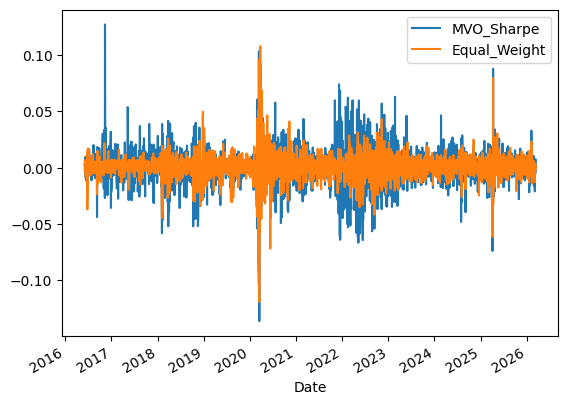

In [160]:
portf_returns_df.plot()

In [161]:
print_table_performance_metrics(portf_returns_df)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
MVO_Sharpe,0.22,0.26,0.58,-0.54
Equal_Weight,0.18,0.18,0.64,-0.37


Text(0.5, 0, 'Date')

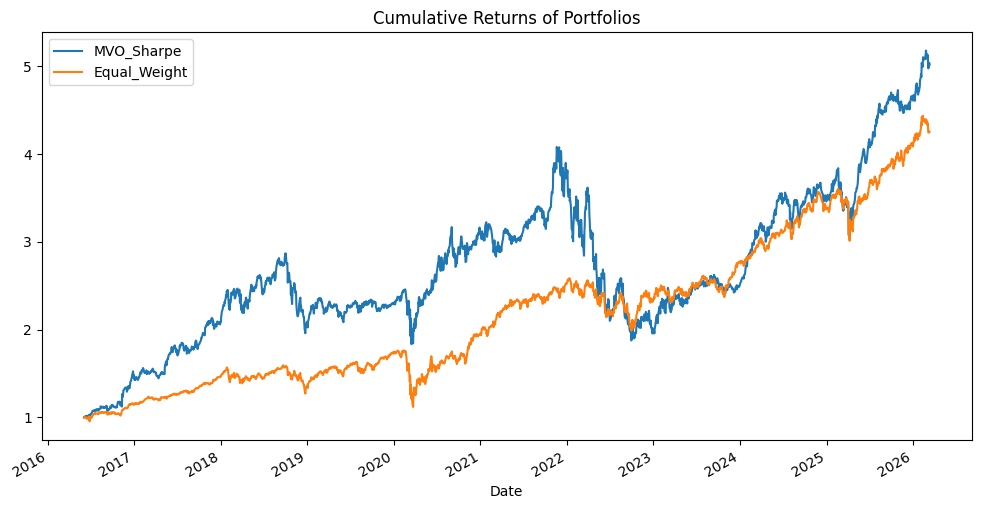

In [162]:
# Portfolio returns
# make a plot with the evolution over the years
 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for col in portf_returns_df.columns:
    (1 + portf_returns_df[col]).cumprod().plot(label=col)
plt.title("Cumulative Returns of Portfolios")
#legend
plt.legend()
plt.xlabel("Date")

### Concrete Example rolling vs expanding window

In [51]:
# Example rolling window
# Quick debug: Compare rolling vs expanding windows
import pandas as pd
import numpy as np

# Create sample data
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=20, freq='D')
returns = pd.DataFrame(np.random.randn(20, 3) * 0.01, index=dates, columns=['A', 'B', 'C'])

print("="*70)
print("SAMPLE DATA (20 days, 3 assets)")
print(f"Index: {returns.index[0]} → {returns.index[-1]}")
print("="*70)

lookback = 5
optimize_every = 5
T = len(returns)

print(f"\nParameters: lookback={lookback}, optimize_every={optimize_every}, T={T}\n")

# ─────────────────────────────────────────────────────────────────────
print("ROLLING WINDOW (Fixed size)")
print("─" * 70)
for t in range(lookback, T):
    if (t - lookback) % optimize_every == 0:
        # ROLLING: Always lookback periods
        train_start = t - lookback
        train_end = t
        train_data = returns.iloc[train_start:train_end]
        
        print(f"t={t:2d} | Reoptimize | Train window: [{train_start:2d}:{train_end:2d}] | "
              f"Length: {len(train_data):2d} | "
              f"Dates: {train_data.index[0].date()} → {train_data.index[-1].date()}")

# ─────────────────────────────────────────────────────────────────────
print("\n\nEXPANDING WINDOW (Growing size)")
print("─" * 70)
for t in range(lookback, T):
    if (t - lookback) % optimize_every == 0:
        # EXPANDING: From start to current t
        train_start = 0
        train_end = t
        train_data = returns.iloc[train_start:train_end]
        
        print(f"t={t:2d} | Reoptimize | Train window: [{train_start:2d}:{train_end:2d}] | "
              f"Length: {len(train_data):2d} | "
              f"Dates: {train_data.index[0].date()} → {train_data.index[-1].date()}")

# ─────────────────────────────────────────────────────────────────────
print("\n\nHYBRID WINDOW (Capped expanding)")
print("─" * 70)
cap = 2 * lookback  # Cap at 2x lookback

for t in range(lookback, T):
    if (t - lookback) % optimize_every == 0:
        # HYBRID: Expand but cap at max_window
        train_start = max(0, t - cap)
        train_end = t
        train_data = returns.iloc[train_start:train_end]
        
        print(f"t={t:2d} | Reoptimize | Train window: [{train_start:2d}:{train_end:2d}] | "
              f"Length: {len(train_data):2d} | "
              f"Dates: {train_data.index[0].date()} → {train_data.index[-1].date()}")

SAMPLE DATA (20 days, 3 assets)
Index: 2020-01-01 00:00:00 → 2020-01-20 00:00:00

Parameters: lookback=5, optimize_every=5, T=20

ROLLING WINDOW (Fixed size)
──────────────────────────────────────────────────────────────────────
t= 5 | Reoptimize | Train window: [ 0: 5] | Length:  5 | Dates: 2020-01-01 → 2020-01-05
t=10 | Reoptimize | Train window: [ 5:10] | Length:  5 | Dates: 2020-01-06 → 2020-01-10
t=15 | Reoptimize | Train window: [10:15] | Length:  5 | Dates: 2020-01-11 → 2020-01-15


EXPANDING WINDOW (Growing size)
──────────────────────────────────────────────────────────────────────
t= 5 | Reoptimize | Train window: [ 0: 5] | Length:  5 | Dates: 2020-01-01 → 2020-01-05
t=10 | Reoptimize | Train window: [ 0:10] | Length: 10 | Dates: 2020-01-01 → 2020-01-10
t=15 | Reoptimize | Train window: [ 0:15] | Length: 15 | Dates: 2020-01-01 → 2020-01-15


HYBRID WINDOW (Capped expanding)
──────────────────────────────────────────────────────────────────────
t= 5 | Reoptimize | Train window

# Incorporation of expanding window

In [69]:
from typing import Dict, Tuple, Callable
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier

# Current function to updrade

def backtest_exp_w(
    portfolio_funcs: Dict[str, Callable],
    prices: pd.DataFrame,
    lookback: int,
    optimize_every: int = 1,
    verbose: bool = True
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Walk-forward backtester for multiple portfolio strategies.
    
    Args:
        portfolio_funcs: Dict of {strategy_name: optimization_function}
        prices: DataFrame with asset prices (index=dates, columns=tickers)
        lookback: Training window size (in periods)
        optimize_every: Reoptimization frequency (in periods)
        verbose: Print progress
    
    Returns:
        Tuple of (portfolio_returns_df, weights_dict)
    """
    N = prices.shape[1]
    X = prices.pct_change().dropna()
    T = len(X)
    
    portf_rets = {}
    ws = {}

    for portfolio_name, portfolio_func in portfolio_funcs.items():
        if verbose:
            print(f"Backtesting portfolio: {portfolio_name}...")
            print(f"  Total periods: {T}, Lookback: {lookback}, OOS periods: {T - lookback}\n")

        # Initialize variables
        current_w = np.repeat(0, N)  # Start with zero weight (will be set at first optimization)
        w = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
        portf_ret = pd.Series(index=X.index,  dtype=float)
        portf_ret.name = portfolio_name

        for t in range(lookback, T):
            # Reoptimize portfolio if necessary
            if (t - lookback) % optimize_every == 0:
                    
                    train_data = X.iloc[0: t]
                    print(f"Reoptimizing lookback at t={t} ({X.index[t].date()})...")
                    # show min date and max date
                    print(f"  [DEBUG] Training data range: {train_data.index[0].date()} to {train_data.index[-1].date()}")
                    #print(f"  [DEBUG] Training data shape: {train_data.shape}")
                    new_w = portfolio_func(train_data)
                    current_w = new_w

            # Store weights
            w.iloc[t] = current_w

            # Calculate portfolio return for this period (before rebalancing)
            print(f"[Debug] Test date: {X.index[t].date()}")
            Portfolio_period_return = (X.iloc[t] * current_w).sum()
            portf_ret.iloc[t] = Portfolio_period_return  # Store in Series

            #if verbose:
               # row_date = X.index[t]
                #row_contrib = (X.iloc[t] * current_w)
                #print(f"  [DEBUG] OOS date: {row_date.date()}, return: {Portfolio_period_return:.6f}, n_assets: {len(current_w)}")
                #print(f"  [DEBUG] Top contributions:\n{row_contrib.sort_values(ascending=False).head(5)}")
                #print(f"  [DEBUG] Bottom contributions:\n{row_contrib.sort_values(ascending=True).head(5)}")


            # Update weights based on asset performance (drift)
            current_w = current_w * (1 + X.iloc[t])
            current_w = current_w / current_w.sum()

        # Keep a record (remove initial NaNs)
        portf_rets[portfolio_name] = portf_ret[lookback:]
        ws[portfolio_name] = w[lookback:]

    # Combine all portfolio returns into a single DataFrame
    portf_rets_df = pd.DataFrame(portf_rets)

    return portf_rets_df, ws




In [ ]:
# Match with cp intervals, start date 2013-06-01 00:00:00
Daily_prices=Daily_prices[Daily_prices.index >= '2013-06-01 00:00:00'].copy()

In [ ]:
# Same inputs but dif backtest funct
# ── Run backtest ─────────────────────────────────────────────────────────────

# Use daily returns
lookback_days = 756  # 3 years
print(f"Daily data: {len(Daily_prices)} trading days")
print(f"Lookback window: {lookback_days} days\n")


portfolio_functions = {
    'max_Sharpe':  max_sharpe,
    'Equal_Weight':  equal_weight_optimizer,
    'HRP':  HRP,
    'MVO':  MVO,
    'cp_max_sharpe': cp_max_sharpe,
}

portf_returns_df, weights_dict = backtest_exp_w(
    portfolio_funcs=portfolio_functions,
    prices=Daily_prices,
    lookback=lookback_days,
   # rebalance_every=21,  # Monthly (≈21 trading days)
    optimize_every=21,   # Quarterly (≈63 trading days)
    #cost_bps=10,         # 10 basis points per transaction
    verbose=True
)

print("\n" + "="*70)
print(portf_returns_df.describe())

Daily data: 3213 trading days
Lookback window: 756 days



NameError: name 'backtest_exp_w' is not defined

In [ ]:
#Portfolio metrics
print_table_performance_metrics(portf_returns_df)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
MVO_Sharpe,0.25,0.22,0.80,-0.43
Equal_Weight,0.15,0.20,0.47,-0.57
HRP,0.14,0.17,0.49,-0.45


# Conformal prediction incorporation

#### Alternative 1: Daily forecast

In [16]:
# inputs: Retornos de los assets...

Daily_returns= Daily_prices.pct_change().dropna()



In [17]:
Daily_returns

,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-05,0.032756,0.041824,0.015421,0.000000,0.026397,0.008796,0.001905,0.002908,0.016123,0.027223,...,0.032496,0.026723,0.004950,0.015869,0.034812,0.002526,-0.048103,0.028936,-0.003442,0.023381
2004-01-06,-0.007477,-0.003609,-0.002359,0.003208,-0.004505,0.001661,-0.003328,-0.001639,0.001004,-0.017668,...,0.040708,-0.000548,-0.005026,0.015904,0.002588,-0.007557,0.010320,0.016542,0.023408,-0.006734
2004-01-07,-0.007535,0.022636,0.012268,0.013269,-0.021309,0.002902,0.008347,-0.002273,0.001404,-0.010912,...,0.008869,0.008498,-0.008891,-0.004752,0.014769,0.000000,0.009335,0.002056,0.002625,-0.007264
2004-01-08,0.012042,0.034086,0.008760,-0.000316,-0.031985,-0.002893,0.013718,0.000506,0.004207,-0.007758,...,0.003597,-0.009242,0.010500,0.007023,0.018081,0.006345,0.002094,0.015318,-0.004114,-0.002439
2004-01-09,-0.036472,-0.015412,0.000579,-0.005682,0.026871,-0.007461,-0.005133,-0.008855,-0.004589,-0.017104,...,0.014337,-0.010699,0.005145,-0.015900,-0.050381,0.016646,-0.009054,-0.029095,-0.016147,-0.014915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-05,-0.019009,-0.008495,0.022605,-0.030770,0.009778,-0.012853,-0.023096,-0.009741,-0.021290,-0.035370,...,0.001639,-0.000376,-0.027227,-0.035148,-0.000345,-0.017274,-0.010926,-0.000391,-0.035209,0.006274
2026-03-06,-0.012090,-0.010873,-0.016860,0.005250,-0.026172,-0.020214,0.040755,-0.017969,-0.022212,-0.035662,...,-0.030108,0.016535,-0.002338,-0.016605,-0.011391,-0.001076,-0.007930,-0.001172,0.003974,0.002985
2026-03-09,0.025314,0.009400,-0.013974,0.020134,0.001313,0.014552,-0.026438,-0.015214,0.000563,0.035130,...,0.027162,-0.008872,0.010350,0.010671,-0.038757,-0.010186,0.003166,-0.013106,0.004362,-0.005092


In [43]:
# implement conformal prediction.
def conformal_ER(returns_df, alpha=0.1):
    """
    Conformal prediction for expected returns.
    
    Args:
        returns_df: DataFrame with date index and ticker columns containing period returns
        alpha: Significance level (e.g., 0.1 for 90% confidence)

    Returns:
        DataFrame with lower and upper bounds for expected returns
    """
    # Step 1: Calculate residuals (absolute errors) from a simple model (e.g., mean return)
    mean_returns = returns_df.mean()
    residuals = (returns_df - mean_returns).abs()

    # Step 2: Calculate the quantile of residuals for the given alpha
    quantile = residuals.stack().quantile(1 - alpha)

    # Step 3: Construct prediction intervals
    lower_bound = mean_returns - quantile
    upper_bound = mean_returns + quantile

    # Combine into a DataFrame
    intervals_df = pd.DataFrame({
        'Mean_Return': mean_returns,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

    return intervals_df

In [ ]:
"""
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_cumulative_returns(returns_df: pd.DataFrame, title: str = "Cumulative Returns"):
    """
    Plot cumulative returns for each ticker in the DataFrame.
    
    Args:
        returns_df: DataFrame with date index and ticker columns containing period returns
        title: Plot title
    """
    cumulative = (1 + returns_df).cumprod() - 1

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

    # --- Top panel: Cumulative returns ---
    ax1 = axes[0]
    for col in cumulative.columns:
        ax1.plot(cumulative.index, cumulative[col] * 100, label=col, linewidth=1.5)

    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel("Cumulative Return (%)", fontsize=11)
    ax1.legend(loc='upper left', framealpha=0.9, fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # --- Bottom panel: Rolling 30-period volatility ---
    ax2 = axes[1]
    for col in returns_df.columns:
        rolling_vol = returns_df[col].rolling(30).std() * 100
        ax2.plot(returns_df.index, rolling_vol, label=col, linewidth=1.2)

    ax2.set_ylabel("Rolling Vol (%)", fontsize=10)
    ax2.set_xlabel("Date", fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()
    return fig


plot_cumulative_returns(Daily_returns, title="Portfolio Returns")
"""

In [ ]:
# inputs: Retornos de los assets...

df_long = (Daily_returns.reset_index()
             .melt(id_vars="Date", var_name="unique_id", value_name="y")
             .rename(columns={"Date": "ds"}))

In [50]:
df_long[(df_long["unique_id"]=="AAPL") & (df_long["ds"]=="2025-04-09")]

,ds,unique_id,y
10931,2025-04-09,AAPL,0.153288


In [54]:
(198.85-172.42)/172.42

0.15328848161466194

In [19]:
train = df_long

In [17]:
train.min()

ds           2004-01-05 00:00:00
unique_id                     AA
y                      -0.607908
dtype: object

In [18]:
train["ds"].max()

Timestamp('2026-03-11 00:00:00')

In [222]:
# limit train for computing limitations test
# 1. only 5 tickers [AAPL, MSFT, GOOG, AMZN, META]
tickers_to_use = ['AAPL']
Daily_returns_subset = train[train["unique_id"].isin(tickers_to_use)]
#Daily_returns_subset = Daily_returns_subset.query("ds >= '2024-01-01'")     

In [223]:
Daily_returns_subset

,ds,unique_id,y
5581,2004-01-05,AAPL,0.041824
5582,2004-01-06,AAPL,-0.003609
5583,2004-01-07,AAPL,0.022636
5584,2004-01-08,AAPL,0.034086
5585,2004-01-09,AAPL,-0.015412
...,...,...,...
11157,2026-03-05,AAPL,-0.008495
11158,2026-03-06,AAPL,-0.010873
11159,2026-03-09,AAPL,0.009400
11160,2026-03-10,AAPL,0.003655


In [32]:
Daily_returns_subset = Daily_returns_subset.reset_index(drop=True)

idx = 252 * 3  # 756
print(Daily_returns_subset.loc[idx, 'ds'])

2007-01-05 00:00:00


In [34]:
target_date = '2007-05-30 00:00:00'
idx = Daily_returns_subset[Daily_returns_subset['ds'] == target_date].index[0]
idx

855

In [224]:
# Create a list of models and instantiation parameters
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.models import AutoETS
from statsforecast.models import WindowAverage, Naive, RandomWalkWithDrift


from statsforecast.utils import ConformalIntervals


h2=63  # horizon of the forecast (e.g., 63 trading days ≈ 3 months), test 1 mes= 20 trading days
h=1  # horizon of the forecast (e.g., 63 trading days ≈ 3 months), test 1 mes= 20 trading days
h1=1  # forecast 1 next day to rebalance daily 
m=100 # for test lets use m=2, now= 3, 

intervals = ConformalIntervals(h=h, n_windows=m)

w = 756  # Use the past 3 years (252*3) for the rolling average

models = [
    WindowAverage(window_size=w, prediction_intervals=intervals),
    Naive(prediction_intervals=intervals),
    RandomWalkWithDrift(prediction_intervals=intervals)
#    AutoETS(season_length=5,prediction_intervals=intervals),
 #   AutoARIMA(season_length=5, prediction_intervals=intervals)
]

In [38]:
(5581- 3*252 - 63) // 63    #

75

In [225]:
# Time series cross validation
# First attemp
sf = StatsForecast(models=models, freq="B", n_jobs=-1, verbose= True)

levels=[80, 85,90]

# forecasting 20 dias (h) with a moving avergae of 20 dias.....Average of past month= forecast of next month....
# forecasting 20 dias (h) with a moving avergae of 63 dias.....Average of 3 month= forecast of next month.... pero el ofrecast de 20 dias eeuivale al ultimo ma calculado.

n_w2= (2790- 1095 - 63) // 63
n_w3= (5581- 1095 - 63) // 63
n_w4= (5581- 3*252 - 63) // 63
n_w4= (len(Daily_returns_subset)- 3*252 - 1) // 1

n_w=(5284 - 1095 - 63) // 63

cv_df = sf.cross_validation(
    df = Daily_returns_subset,
    h = h,   #horizon of forecast.
    step_size = h,  # how much data to add to each cv.normally equal to h
    n_windows = n_w4,  # cantidad de  windows. trimestre = nr años/ dias por trimestre. ->252*20/63 
    level=levels,
  )


Cross Validation Time Series 1: 100%|██████████| 4824/4824 [04:21<00:00, 18.46it/s]


In [226]:
# y and windoeavergae to percentage
#cv_df['actual'] = cv_df['actual'] * 100
#cv_df['WindowAverage'] = cv_df['WindowAverage'] * 100
#cv_df['WindowAverage-lo-95'] = cv_df['WindowAverage-lo-95'] * 100
#cv_df['WindowAverage-hi-95'] = cv_df['WindowAverage-hi-95'] * 100
cv_df

,unique_id,ds,cutoff,y,WindowAverage,WindowAverage-lo-90,WindowAverage-lo-85,WindowAverage-lo-80,WindowAverage-hi-80,WindowAverage-hi-85,...,Naive-hi-80,Naive-hi-85,Naive-hi-90,RWD,RWD-lo-90,RWD-lo-85,RWD-lo-80,RWD-hi-80,RWD-hi-85,RWD-hi-90
0,AAPL,2007-01-08,2007-01-05,0.004938,0.003000,NaN,NaN,NaN,NaN,NaN,...,0.027604,0.030312,0.036363,-0.007186,-0.050672,-0.044588,-0.041958,0.027585,0.030216,0.036300
1,AAPL,2007-01-09,2007-01-08,0.083069,0.003011,NaN,NaN,NaN,NaN,NaN,...,0.039664,0.042372,0.048422,0.004890,-0.038596,-0.032513,-0.029882,0.039661,0.042292,0.048375
2,AAPL,2007-01-10,2007-01-09,0.047856,0.003091,NaN,NaN,NaN,NaN,NaN,...,0.118082,0.120734,0.128275,0.083124,0.037824,0.045414,0.048147,0.118101,0.120834,0.128424
3,AAPL,2007-01-11,2007-01-10,-0.012371,0.003109,NaN,NaN,NaN,NaN,NaN,...,0.083096,0.085520,0.093061,0.047864,0.002564,0.010154,0.012566,0.083162,0.085574,0.093164
4,AAPL,2007-01-12,2007-01-11,-0.012317,0.003113,NaN,NaN,NaN,NaN,NaN,...,0.023117,0.027042,0.035341,-0.012442,-0.060183,-0.051842,-0.048019,0.023134,0.026958,0.035298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4819,AAPL,2026-03-05,2026-03-04,-0.008495,0.000908,-0.021004,-0.017895,-0.014525,0.016341,0.019711,...,0.017109,0.022838,0.024962,-0.004672,-0.034307,-0.032166,-0.026439,0.017095,0.022822,0.024963
4820,AAPL,2026-03-06,2026-03-05,-0.010873,0.000902,-0.021010,-0.017902,-0.014271,0.016074,0.019705,...,0.012445,0.019007,0.021131,-0.008504,-0.038139,-0.035998,-0.029452,0.012445,0.018991,0.021132
4821,AAPL,2026-03-09,2026-03-06,0.009400,0.000906,-0.020638,-0.017730,-0.014072,0.015884,0.019542,...,0.010067,0.016629,0.018753,-0.010882,-0.040517,-0.038376,-0.031831,0.010067,0.016612,0.018753
4822,AAPL,2026-03-10,2026-03-09,0.003655,0.000913,-0.020631,-0.017723,-0.014065,0.015891,0.019549,...,0.029726,0.036664,0.037748,0.009394,-0.018964,-0.017885,-0.010942,0.029729,0.036673,0.037752


In [241]:
#analisis of lo -95

display(cv_df["WindowAverage-lo-90"].describe())
display(cv_df["WindowAverage-lo-85"].describe())
display(cv_df["WindowAverage-lo-80"].describe())
display(cv_df["Naive-lo-90"].describe())
display(cv_df["Naive-lo-80"].describe())


count    4725.000000
mean       -0.027280
std         0.010730
min        -0.071252
25%        -0.032480
50%        -0.024680
75%        -0.020319
max        -0.009266
Name: WindowAverage-lo-90, dtype: float64

count    4725.000000
mean       -0.023151
std         0.009235
min        -0.065701
25%        -0.027437
50%        -0.020740
75%        -0.016792
max        -0.007705
Name: WindowAverage-lo-85, dtype: float64

count    4725.000000
mean       -0.019936
std         0.007985
min        -0.059506
25%        -0.023784
50%        -0.017663
75%        -0.014563
max        -0.007017
Name: WindowAverage-lo-80, dtype: float64

count    4824.000000
mean       -0.039916
std         0.026014
min        -0.242215
25%        -0.051011
50%        -0.035647
75%        -0.024323
max         0.116225
Name: Naive-lo-90, dtype: float64

count    4824.000000
mean       -0.029112
std         0.023173
min        -0.226197
25%        -0.039419
50%        -0.026188
75%        -0.015456
max         0.126060
Name: Naive-lo-80, dtype: float64

In [228]:
# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse
from utilsforecast.losses import mae, coverage, scaled_crps, mase, rmae
from functools import partial
# Rename 'y' to 'actual' for the evaluation function
cv_df = cv_df.rename(columns={'y': 'actual'})

Daily_returns_subset = Daily_returns_subset.rename(columns={'y': 'actual'})  # Add this line

mase_naive = partial(mase, seasonality=1)
rmae_naive = partial(rmae, baseline="Naive")

cv_rmse = evaluate(cv_df, train_df=Daily_returns_subset, metrics=[rmse, mae, coverage,scaled_crps, mase_naive, rmae_naive], level=levels, models=['WindowAverage', "Naive","RWD"], target_col='actual', agg_fn='mean')
print(f"RMSE using cross-validation:")
cv_rmse


RMSE using cross-validation:


,cutoff,metric,WindowAverage,Naive,RWD
0,2007-01-05,rmse,0.001938,0.012060,0.012125
1,2007-01-08,rmse,0.080058,0.078131,0.078180
2,2007-01-09,rmse,0.044765,0.035214,0.035268
3,2007-01-10,rmse,0.015480,0.060227,0.060235
4,2007-01-11,rmse,0.015431,0.000054,0.000125
...,...,...,...,...,...
38587,2026-03-04,rmae_Naive,2.454411,1.000000,0.997823
38588,2026-03-05,rmae_Naive,4.951198,1.000000,0.996205
38589,2026-03-06,rmae_Naive,0.418976,1.000000,1.000466
38590,2026-03-09,rmae_Naive,0.477437,1.000000,0.998988


In [229]:
df_wide = cv_rmse.pivot(index="cutoff", columns="metric", values=["WindowAverage","Naive","RWD"])
df_wide.columns.name = None
df_wide = df_wide.reset_index()
df_wide

cutoff    WindowAverage                                    \
metric            coverage_level80 coverage_level85 coverage_level90   
0      2007-01-05              0.0              0.0              0.0   
1      2007-01-08              0.0              0.0              0.0   
2      2007-01-09              0.0              0.0              0.0   
3      2007-01-10              0.0              0.0              0.0   
4      2007-01-11              0.0              0.0              0.0   
...           ...              ...              ...              ...   
4819   2026-03-04              1.0              1.0              1.0   
4820   2026-03-05              1.0              1.0              1.0   
4821   2026-03-06              1.0              1.0              1.0   
4822   2026-03-09              1.0              1.0              1.0   
4823   2026-03-10              1.0              1.0              1.0   

                                                                        Naive  \
metric       mae      mase  rmae_Naive      rmse scaled_crps coverage_level80   
0       0.001938  0.072314    0.160740  0.001938         NaN              1.0   
1       0.080058  2.988673    1.024666  0.080058         NaN              0.0   
2       0.044765  1.666909    1.271238  0.044765         NaN              0.0   
3       0.015480  0.576209    0.257035  0.015480         NaN              0.0   
4       0.015431  0.573427  287.867625  0.015431         NaN              1.0   
...          ...       ...         ...       ...         ...              ...   
4819    0.009403  0.456389    2.454411  0.009403   -0.317783              1.0   
4820    0.011774  0.571573    4.951198  0.011774   -0.246683              1.0   
4821    0.008494  0.412382    0.418976  0.008494    0.281768              1.0   
4822    0.002742  0.133153    0.477437  0.002742    0.724531              1.0   
4823    0.000565  0.027419    0.168619  0.000565    8.633251              1.0   

        ...                                    RWD                   \
metric  ...      rmse scaled_crps coverage_level80 coverage_level85   
0       ...  0.012060    1.141276              1.0              1.0   
1       ...  0.078131    0.544360              0.0              0.0   
2       ...  0.035214    0.121014              0.0              1.0   
3       ...  0.060227   -2.149921              0.0              0.0   
4       ...  0.000054   -0.481181              1.0              1.0   
...     ...       ...         ...              ...              ...   
4819    ...  0.003831   -0.449009              1.0              1.0   
4820    ...  0.002378   -0.345691              1.0              1.0   
4821    ...  0.020272    0.399863              1.0              1.0   
4822    ...  0.005744    1.002131              1.0              1.0   
4823    ...  0.003349   11.941022              1.0              1.0   

                                                                              
metric coverage_level90       mae      mase rmae_Naive      rmse scaled_crps  
0                   1.0  0.012125  0.452295   1.005368  0.012125    1.141600  
1                   0.0  0.078180  2.918547   1.000624  0.078180    0.544897  
2                   1.0  0.035268  1.313275   1.001545  0.035268    0.121703  
3                   0.0  0.060235  2.242053   1.000132  0.060235   -2.145951  
4                   1.0  0.000125  0.004642   2.330290  0.000125   -0.481685  
...                 ...       ...       ...        ...       ...         ...  
4819                1.0  0.003823  0.185542   0.997823  0.003823   -0.448955  
4820                1.0  0.002369  0.115003   0.996205  0.002369   -0.345744  
4821                1.0  0.020282  0.984721   1.000466  0.020282    0.399924  
4822                1.0  0.005738  0.278609   0.998988  0.005738    1.002589  
4823                1.0  0.003342  0.162276   0.997957  0.003342   11.946487  

[4824 rows x 25 columns]

In [240]:
from deel.puncc import metrics

def prob_metrics(cv_df, alpha,model):
    """
    Calculate probabilistic forecasting metrics: coverage, sharpness, and ACE.
    
    Args:
        cv_df: DataFrame containing 'actual', 'WindowAverage-lo-95', and 'WindowAverage-hi-95' columns
    
    Returns:
        Dictionary with coverage, average width, and ACE
    """
    level= int((1-alpha)*100)
    y_test = cv_df['actual']
    y_pred_lower = cv_df[f'{model}-lo-{level}']
    y_pred_upper = cv_df[f'{model}-hi-{level}']

    coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
    width = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                        y_pred_upper=y_pred_upper)
    ACE = metrics.regression_ace(y_test, y_pred_lower, y_pred_upper,alpha)
    print(f"\nProbabilistic metrics for {model} at alpha={alpha}:")
    print(f"Marginal coverage: {coverage}")
    print(f"Average width: {width*100:.2f}%")
    print(f"Average coverage error: {ACE*100:.2f}%")


prob_metrics(cv_df, alpha=0.1, model="WindowAverage")
prob_metrics(cv_df, alpha=0.1, model="Naive")
prob_metrics(cv_df, alpha=0.1, model="RWD")
prob_metrics(cv_df, alpha=0.15, model="WindowAverage")
prob_metrics(cv_df, alpha=0.15, model="Naive")
prob_metrics(cv_df, alpha=0.15, model="RWD")
prob_metrics(cv_df, alpha=0.2, model="WindowAverage")
prob_metrics(cv_df, alpha=0.2, model="Naive")
prob_metrics(cv_df, alpha=0.2, model="RWD")


Probabilistic metrics for WindowAverage at alpha=0.1:
Marginal coverage: 0.8654643449419569
Average width: 5.71%
Average coverage error: -3.45%

Probabilistic metrics for Naive at alpha=0.1:
Marginal coverage: 0.8837064676616916
Average width: 8.21%
Average coverage error: -1.63%

Probabilistic metrics for RWD at alpha=0.1:
Marginal coverage: 0.8837064676616916
Average width: 8.22%
Average coverage error: -1.63%

Probabilistic metrics for WindowAverage at alpha=0.15:
Marginal coverage: 0.8190298507462687
Average width: 4.88%
Average coverage error: -3.10%

Probabilistic metrics for Naive at alpha=0.15:
Marginal coverage: 0.8422470978441128
Average width: 6.96%
Average coverage error: -0.78%

Probabilistic metrics for RWD at alpha=0.15:
Marginal coverage: 0.8420398009950248
Average width: 6.96%
Average coverage error: -0.80%

Probabilistic metrics for WindowAverage at alpha=0.2:
Marginal coverage: 0.7786069651741293
Average width: 4.24%
Average coverage error: -2.14%

Probabilistic met

In [ ]:
y_pred_lower = cv_df['Naive-lo-95']
y_pred_upper = cv_df['Naive-hi-95']

coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
width = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                     y_pred_upper=y_pred_upper)

ACE = metrics.regression_ace(y_test, y_pred_lower, y_pred_upper,0.05)

print(f"Marginal coverage: {coverage}")
print(f"Average width: {width*100:.2f}%")
print(f"Average coverage error: {ACE*100:.2f}%")

Marginal coverage: 0.9398839137645107
Average width: 10.64%
Average coverage error: -1.01%


In [219]:
y_pred_lower2 = cv_df['RWD-lo-95']
y_pred_upper2 = cv_df['RWD-hi-95']

coverage = metrics.regression_mean_coverage(y_test, y_pred_lower2, y_pred_upper2)
width = metrics.regression_sharpness(y_pred_lower=y_pred_lower2,
                                     y_pred_upper=y_pred_upper2)
ACE = metrics.regression_ace(y_test, y_pred_lower2, y_pred_upper2,0.05)
print(f"Marginal coverage: {coverage}")
print(f"Average width: {width*100:.2f}%")
print(f"Average coverage error: {ACE*100:.2f}%")

Marginal coverage: 0.9398839137645107
Average width: 10.64%
Average coverage error: -1.01%


In [197]:
#coverage
print(df_wide[('Naive', 'coverage_level95')].sum() / len(df_wide)*100)
print(df_wide[('WindowAverage', 'coverage_level95')].sum() / len(df_wide)*100)
print(df_wide[('RWD', 'coverage_level95')].sum() / len(df_wide)*100)



93.07628524046434
91.83250414593698
93.07628524046434


In [82]:
#df_wide[df_wide["scaled_crps"]<25][["scaled_crps"]].dropna().mean()
df_wide[df_wide["scaled_crps"] < 25]["scaled_crps"].dropna().mean()

0.00627588792029989

In [135]:
# Count rMAE values > 1 and < 1
rmae_col = ('WindowAverage', 'rmae_Naive')  # or just 'rmae' depending on the column name



# Then count:
rmae_greater_than_1 = (df_wide[rmae_col] > 1).sum()
rmae_less_than_1 = (df_wide[rmae_col] < 1).sum()
rmae_equal_to_1 = (df_wide[rmae_col] == 1).sum()

print(f"\nrMAE > 1 (worse than naive): {rmae_greater_than_1}")
print(f"rMAE < 1 (better than naive): {rmae_less_than_1}")
print(f"rMAE = 1 (equal to naive): {rmae_equal_to_1}")
print(f"Total rows: {len(df_wide)}")
print(f"\nPercentage better than naive: {rmae_less_than_1 / len(df_wide) * 100:.1f}%")


rMAE > 1 (worse than naive): 1710
rMAE < 1 (better than naive): 3114
rMAE = 1 (equal to naive): 0
Total rows: 4824

Percentage better than naive: 64.6%


In [ ]:
#FVA


In [ ]:
#rMAE insteand oF MASE.


In [40]:
total_rows= 5581
n_windows = n_w4
step_size = h
first_cutoff_index = total_rows - (n_windows * step_size) - h + step_size - 1
first_cutoff_index

855

In [60]:
total_rows= 5581
n_windows = 77
step_size = h
first_cutoff_index = total_rows - (n_windows * step_size) - h + step_size - 1
first_cutoff_index

729

In [42]:
# how many windows to reach back to row 756 (first valid cutoff)?
n_windows = (total_rows - 756) // h
print(n_windows)  # this should push the first cutoff back to ~row 756

76


In [30]:
cutoff = cv_df['cutoff'].nunique()
cutoff

75

In [ ]:
"""

from IPython.display import display
cv_df.rename(columns = {'y' : 'actual'}, inplace = True) # rename actual values

cutoff = cv_df['cutoff'].unique()

for k in range(len(cutoff)):
    cv = cv_df[cv_df['cutoff'] == cutoff[k]]
    display(StatsForecast.plot(Daily_returns_subset, cv.loc[:, cv.columns != 'cutoff']))
from IPython.display import display
import matplotlib.pyplot as plt

# keep actual column available
cv_df = cv_df.rename(columns={'y': 'actual'})

cutoff_date="2007-04-09 00:00:00"

cutoff_values = sorted(cv_df['cutoff'].unique())

for cutoff_date in cutoff_values:
    cv = cv_df[cv_df['cutoff'] == cutoff_date]
    df_until_cutoff = Daily_returns_subset[Daily_returns_subset['ds'] <= cutoff_date].rename(columns={'y': 'actual'})

    # optional: join for consistent axis
    combined = cv[['ds', 'actual', 'WindowAverage', 'WindowAverage-lo-95', 'WindowAverage-hi-95']]

    plt.figure(figsize=(10, 4))
    plt.plot(df_until_cutoff['ds'], df_until_cutoff['actual'], label='actual (up to cutoff)')
    if 'WindowAverage' in cv.columns:
        plt.plot(combined['ds'], combined['WindowAverage'], label='forecast (CV window)')
    plt.axvline(cutoff_date, color='red', linestyle='--', label='cutoff')
    plt.title(f'Cutoff {cutoff_date.date()} - no future data')
    plt.legend()
    plt.show()
"""

#### Alternative 2: Monthly forecast

#####  Data Loading,  transformation and models fit

In [111]:
# inputs: Retornos de los assets...

Monthly_returns= Monthly_prices.pct_change().dropna()
df_long_monthly = (Monthly_returns.reset_index()
             .melt(id_vars="Date", var_name="unique_id", value_name="y")
             .rename(columns={"Date": "ds"}))

In [112]:
# limit train for computing limitations test
# 1. only 5 tickers [AAPL, MSFT, GOOG, AMZN, META]

#All tickers.
train= df_long_monthly

# Subset to test
tickers_to_use = ['AAPL']
#Monthly_returns_subset = df_long_monthly[df_long_monthly["unique_id"].isin(tickers_to_use)]
#Daily_returns_subset = Daily_returns_subset.query("ds >= '2024-01-01'")     
#Monthly_returns_subset = Monthly_returns_subset.reset_index(drop=True)
#train =Monthly_returns_subset.copy()

train

,ds,unique_id,y
0,2006-02-01,AA,-0.069206
1,2006-03-01,AA,0.047279
2,2006-04-01,AA,0.105367
3,2006-05-01,AA,-0.060983
4,2006-06-01,AA,0.024660
...,...,...,...
10159,2025-11-01,XOM,0.013641
10160,2025-12-01,XOM,0.047210
10161,2026-01-01,XOM,0.175004
10162,2026-02-01,XOM,0.078501


In [138]:
# Covariance matrix between all tickers
cov_matrix = train.pivot(index='ds', columns='unique_id', values='actual').cov()
cov_matrix

unique_id,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
unique_id,,,,,,,,,,,,,,,,,,,,,
AA,0.014539,0.003152,0.002744,0.001600,0.002087,0.002309,0.002610,0.003285,0.003716,0.005075,...,0.005142,0.001254,0.000957,0.002167,0.001235,0.001264,0.001497,0.001197,0.000658,0.001449
AAPL,0.003152,0.006596,0.000897,0.000829,0.002741,0.001236,0.001507,0.001813,0.002080,0.001553,...,0.004095,0.000778,0.000871,0.001658,0.000730,0.000733,0.001141,0.000606,0.000703,0.000776
AIG,0.002744,0.000897,0.005311,0.000463,0.000760,0.001881,0.001112,0.002840,0.003291,0.001882,...,0.001667,0.000730,0.000375,0.001174,0.000461,0.001700,0.000724,0.000710,0.000089,0.001133
AMGN,0.001600,0.000829,0.000463,0.004323,0.000624,0.000667,0.000944,0.001353,0.001365,0.001133,...,0.000974,0.001429,0.000785,0.001178,0.000809,0.000813,0.000873,0.000981,0.000584,0.000729
AMZN,0.002087,0.002741,0.000760,0.000624,0.007119,0.001345,0.001793,0.001246,0.001941,0.001875,...,0.004795,0.000685,0.000339,0.001415,0.000769,0.001011,0.000993,0.000628,0.000582,0.000803
AXP,0.002309,0.001236,0.001881,0.000667,0.001345,0.003431,0.001444,0.002111,0.002717,0.001979,...,0.001995,0.000486,0.000355,0.001513,0.000593,0.000907,0.000853,0.000598,0.000537,0.000723
BA,0.002610,0.001507,0.001112,0.000944,0.001793,0.001444,0.006135,0.001757,0.002935,0.001669,...,0.002324,0.001065,0.000348,0.001058,0.000333,0.000760,0.000841,0.000476,0.000477,0.000720
BAC,0.003285,0.001813,0.002840,0.001353,0.001246,0.002111,0.001757,0.006608,0.004972,0.002022,...,0.002976,0.001079,0.000534,0.001888,0.000515,0.001422,0.001145,0.000296,0.000607,0.000990
C,0.003716,0.002080,0.003291,0.001365,0.001941,0.002717,0.002935,0.004972,0.008148,0.002978,...,0.003570,0.001008,0.000667,0.001830,0.000798,0.001682,0.001336,0.000548,0.000697,0.001648


In [113]:
# Outlier detection method.
def remove_outliers_iqr(df, col='y', multiplier=1.5):
    """
    Remove outliers using IQR method per ticker.
    
    Parameters
    ----------
    df          : DataFrame with 'unique_id' and target column
    col         : column to check for outliers (default 'y')
    multiplier  : IQR multiplier (default 1.5, use 3.0 for extreme outliers only)
    """
    results = []
    summary = []

    for ticker in df['unique_id'].unique():
        df_ticker = df[df['unique_id'] == ticker].copy()

        Q1  = df_ticker[col].quantile(0.25)
        Q3  = df_ticker[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        mask    = df_ticker[col].between(lower, upper)
        n_out   = (~mask).sum()

        summary.append({
            'Ticker'   : ticker,
            'N_before' : len(df_ticker),
            'N_removed': n_out,
            'N_after'  : mask.sum(),
            'Lower'    : round(lower, 4),
            'Upper'    : round(upper, 4),
        })

        results.append(df_ticker[mask])

    df_clean   = pd.concat(results).reset_index(drop=True)
    summary_df = pd.DataFrame(summary).set_index('Ticker')

    print(f"Total rows removed: {summary_df['N_removed'].sum()} / {len(df)}")
    print(summary_df)

    return df_clean, summary_df


df_clean, outlier_summary = remove_outliers_iqr(train, col='y', multiplier=1.5)

Total rows removed: 318 / 10164
        N_before  N_removed  N_after   Lower   Upper
Ticker                                              
AA           242          8      234 -0.2987  0.3271
AAPL         242          2      240 -0.1997  0.2471
AIG          242         19      223 -0.2085  0.2126
AMGN         242          2      240 -0.1693  0.1840
AMZN         242          7      235 -0.2229  0.2650
AXP          242         16      226 -0.1456  0.1757
BA           242          8      234 -0.2092  0.2293
BAC          242         13      229 -0.2172  0.2446
C            242          8      234 -0.2314  0.2511
CAT          242          6      236 -0.2190  0.2463
CRM          242          4      238 -0.2476  0.2818
CSCO         242          6      236 -0.1635  0.1826
CVX          242          8      234 -0.1434  0.1644
DD           242         24      218 -0.1512  0.1710
DIS          242         10      232 -0.1625  0.1798
GE           242         17      225 -0.1745  0.1895
GS           2

In [120]:
train=df_clean

In [121]:

# Create a list of models and instantiation parameters
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.models import AutoETS
from statsforecast.models import WindowAverage, Naive, RandomWalkWithDrift, HistoricAverage


from statsforecast.utils import ConformalIntervals


h= 1
m=36

intervals = ConformalIntervals(h=h, n_windows=m)

w = 36  # Use the past 3 years (12*3) for the rolling average

models = [
    WindowAverage(window_size=w, prediction_intervals=intervals),
    Naive(prediction_intervals=intervals),
    RandomWalkWithDrift(prediction_intervals=intervals),
    HistoricAverage(prediction_intervals=intervals)

#    AutoETS(season_length=5,prediction_intervals=intervals),
 #   AutoARIMA(season_length=5, prediction_intervals=intervals)
]

# Time series cross validation

sf = StatsForecast(models=models, freq="ME", n_jobs=-1, verbose= True)

levels=[80, 85,90, 95]

# Forecats 1 month ahead.

n_w= (len(Monthly_returns)- w - 1) // 1

cv_df = sf.cross_validation(
    df = train,
    h = h,   #horizon of forecast.
    step_size = h,  # how much data to add to each cv.normally equal to h
    n_windows = n_w,  # cantidad de  windows (test)
    level=levels,
  )


cv_df


,unique_id,ds,cutoff,y,WindowAverage,WindowAverage-lo-95,WindowAverage-lo-90,WindowAverage-lo-85,WindowAverage-lo-80,WindowAverage-hi-80,...,RWD-hi-95,HistoricAverage,HistoricAverage-lo-95,HistoricAverage-lo-90,HistoricAverage-lo-85,HistoricAverage-lo-80,HistoricAverage-hi-80,HistoricAverage-hi-85,HistoricAverage-hi-90,HistoricAverage-hi-95
0,AA,2008-07-01,2008-06-01,-0.052498,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.008816,-0.136915,-0.112535,-0.107628,-0.101836,0.119467,0.125259,0.130167,0.154546
1,AA,2008-08-01,2008-07-01,-0.048001,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.006772,-0.138176,-0.112633,-0.109652,-0.101608,0.115151,0.123196,0.126177,0.151720
2,AA,2008-09-01,2008-08-01,-0.293456,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.005005,-0.139160,-0.112453,-0.111400,-0.101103,0.111113,0.121410,0.122463,0.149170
3,AA,2008-11-01,2008-09-01,-0.064348,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.004322,-0.162382,-0.139296,-0.120793,-0.119517,0.110873,0.112149,0.130653,0.153739
4,AA,2008-12-01,2008-11-01,0.060932,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.006141,-0.163521,-0.139169,-0.122608,-0.119064,0.106782,0.110326,0.126887,0.151240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8605,XOM,2025-10-01,2025-09-01,0.014279,0.006020,-0.099861,-0.084228,-0.063885,-0.051242,0.063281,...,0.147032,0.006504,-0.102356,-0.079135,-0.066107,-0.052884,0.065891,0.079114,0.092142,0.115363
8606,XOM,2025-11-01,2025-10-01,0.013641,0.006800,-0.099080,-0.083447,-0.063105,-0.050462,0.064062,...,0.134081,0.006538,-0.102322,-0.079101,-0.066073,-0.052850,0.065925,0.079148,0.092177,0.115397
8607,XOM,2025-12-01,2025-11-01,0.047210,0.009339,-0.096541,-0.075038,-0.052683,-0.046632,0.065310,...,0.133438,0.006569,-0.102291,-0.073011,-0.060915,-0.052108,0.065246,0.074052,0.086149,0.115428
8608,XOM,2026-02-01,2025-12-01,0.078501,0.010517,-0.095363,-0.073860,-0.051505,-0.045454,0.066488,...,0.167153,0.006746,-0.102113,-0.072833,-0.060737,-0.051931,0.065424,0.074230,0.086326,0.115606


In [152]:
#wide format for backteststrategy
cp_returns = cv_df.pivot(index='ds', columns='unique_id', values='WindowAverage-lo-80')
cp_returns.dropna(inplace=True)
cp_returns

unique_id,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
ds,,,,,,,,,,,,,,,,,,,,,
2013-06-01,-0.133123,-0.075969,-0.103082,-0.043336,-0.084657,-0.057792,-0.058509,-0.129214,-0.127977,-0.092364,...,-0.155382,-0.050057,-0.038471,-0.041376,-0.031996,-0.047136,-0.035858,-0.037308,-0.040982,-0.045476
2013-07-01,-0.120080,-0.085879,-0.102300,-0.044172,-0.068782,-0.058022,-0.056941,-0.130826,-0.128716,-0.089153,...,-0.147408,-0.047528,-0.037884,-0.040486,-0.031544,-0.047821,-0.033954,-0.036746,-0.039731,-0.043942
2013-08-01,-0.120930,-0.098364,-0.099283,-0.043373,-0.068622,-0.051239,-0.056549,-0.124806,-0.128813,-0.088696,...,-0.124369,-0.047759,-0.037236,-0.040852,-0.032111,-0.046259,-0.032821,-0.034719,-0.039792,-0.044167
2013-09-01,-0.119441,-0.094060,-0.097965,-0.041428,-0.073067,-0.041181,-0.049405,-0.123301,-0.128201,-0.091142,...,-0.120998,-0.050195,-0.037403,-0.041628,-0.033400,-0.048363,-0.034403,-0.036774,-0.041446,-0.047293
2013-10-01,-0.094362,-0.076628,-0.094569,-0.041866,-0.073831,-0.037596,-0.048274,-0.123310,-0.129589,-0.089197,...,-0.119748,-0.051606,-0.038363,-0.041965,-0.033915,-0.045866,-0.032444,-0.037714,-0.042491,-0.048769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-01,-0.197774,-0.082602,-0.060902,-0.074052,-0.093320,-0.065620,-0.130428,-0.112734,-0.123529,-0.089723,...,-0.138239,-0.107813,-0.057931,-0.079361,-0.088896,-0.061591,-0.053783,-0.080764,-0.048347,-0.077989
2025-06-01,-0.198462,-0.082795,-0.056367,-0.078644,-0.103366,-0.068142,-0.119695,-0.105988,-0.113775,-0.093029,...,-0.134294,-0.087802,-0.060051,-0.071606,-0.083261,-0.059149,-0.057234,-0.079482,-0.046592,-0.074192
2025-10-01,-0.181979,-0.069305,-0.049868,-0.079472,-0.080197,-0.062738,-0.115096,-0.083910,-0.088623,-0.088747,...,-0.115191,-0.079661,-0.058431,-0.069442,-0.071444,-0.055108,-0.059646,-0.057645,-0.036071,-0.051242


In [134]:
cv_df[cv_df['unique_id'] == 'AAPL']['WindowAverage'].mean()

0.0269556004382975

In [116]:
# Proportion of neg returns and positive return


describe_cv=cv_df["y"].describe()
#add cv 
snr = cv_df["y"].mean() / cv_df["y"].std()
describe_cv.loc["snr"] = snr

display(describe_cv)

count    8610.000000
mean        0.012705
std         0.069382
min        -0.293456
25%        -0.029507
50%         0.012476
75%         0.055561
max         0.336869
snr         0.183122
Name: y, dtype: float64

In [117]:
describe_cv=cv_df["WindowAverage"].describe()
#add cv 
snr = cv_df["WindowAverage"].mean() / cv_df["WindowAverage"].std()
describe_cv.loc["snr"] = snr
display(describe_cv)

count    8333.000000
mean        0.012089
std         0.011435
min        -0.032621
25%         0.005975
50%         0.011728
75%         0.017958
max         0.079063
snr         1.057170
Name: WindowAverage, dtype: float64

In [118]:
describe_cv=cv_df["HistoricAverage"].describe()
#add cv 
snr = cv_df["HistoricAverage"].mean() / cv_df["HistoricAverage"].std()
describe_cv.loc["snr"] = snr
display(describe_cv)

count    8610.000000
mean        0.011030
std         0.007375
min        -0.026967
25%         0.007443
50%         0.010275
75%         0.014834
max         0.046763
snr         1.495686
Name: HistoricAverage, dtype: float64

##### COmprobation of usefulness of lo intervals

In [ ]:
# Check for values of low bound interval

# Columns we care about
lo_cols = [c for c in cv_df.columns if '-lo-' in c]

# Melt to long format: unique_id | model | level | value
lo_long = (
    cv_df[['unique_id'] + lo_cols]
    .melt(id_vars='unique_id', var_name='col', value_name='value')
)

# Parse model and level from column name e.g. "WindowAverage-lo-90"
lo_long[['model', 'level']] = lo_long['col'].str.extract(r'^(.+)-lo-(\d+)$')
lo_long = lo_long.drop(columns='col')

# Describe per (ticker, model, level)
summary = (
    lo_long
    .groupby(['unique_id', 'model', 'level'])['value']
    .describe()
    .round(4)
)

summary

count    mean     std     min     25%  \
unique_id model           level                                          
AA        HistoricAverage 80     205.0 -0.1411  0.0342 -0.2131 -0.1662   
                          85     205.0 -0.1652  0.0419 -0.2393 -0.1951   
                          90     205.0 -0.1887  0.0457 -0.2584 -0.2249   
                          95     205.0 -0.2192  0.0474 -0.2824 -0.2562   
          Naive           80     205.0 -0.2032  0.1490 -0.5752 -0.3164   
...                                ...     ...     ...     ...     ...   
XOM       RWD             95     193.0 -0.1340  0.0599 -0.3104 -0.1741   
          WindowAverage   80     159.0 -0.0609  0.0153 -0.0923 -0.0729   
                          85     159.0 -0.0695  0.0153 -0.1071 -0.0829   
                          90     159.0 -0.0792  0.0164 -0.1172 -0.0920   
                          95     159.0 -0.0919  0.0166 -0.1225 -0.1074   

                                    50%     75%     max  
unique_id model           level                          
AA        HistoricAverage 80    -0.1388 -0.1192 -0.0708  
                          85    -0.1746 -0.1363 -0.0808  
                          90    -0.2007 -0.1497 -0.0842  
                          95    -0.2364 -0.1818 -0.1001  
          Naive           80    -0.1845 -0.1024  0.1603  
...                                 ...     ...     ...  
XOM       RWD             95    -0.1290 -0.0902 -0.0050  
          WindowAverage   80    -0.0554 -0.0492 -0.0330  
                          85    -0.0648 -0.0583 -0.0445  
                          90    -0.0755 -0.0675 -0.0492  
                          95    -0.0889 -0.0800 -0.0585  

[672 rows x 8 columns]

In [123]:
summary["75%"].max()

-0.0296

##### Evaluation metrics creation

In [124]:

#for point metrics. plus crps
from sklearn.metrics import mean_absolute_error, mean_squared_error
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse
from utilsforecast.losses import mae, coverage, scaled_crps, mase, rmae
from functools import partial
# Rename 'y' to 'actual' for the evaluation function
cv_df = cv_df.rename(columns={'y': 'actual'})
train = train.rename(columns={'y': 'actual'})  # Add this line

mase_naive = partial(mase, seasonality=1)
rmae_naive = partial(rmae, baseline="Naive")

cv_df_cutoff=cv_df.copy()
cv_df_cutoff["cutoff"]= pd.to_datetime('2026-02-01 00:00:00')   #dummy to compute the overall metrics across folds.Because we inly have a f horizon of 1 point.

cv_metrics = evaluate(cv_df_cutoff, train_df=train, metrics=[rmse, mae ,scaled_crps, mase_naive, rmae_naive], level=levels, models=['WindowAverage', "Naive","RWD","HistoricAverage"], target_col='actual')



In [125]:
# Per ticker point metrics
cv_metrics

,unique_id,cutoff,metric,WindowAverage,Naive,RWD,HistoricAverage
0,AA,2026-02-01,rmse,0.127379,0.179179,0.180070,0.126074
1,AAPL,2026-02-01,rmse,0.076220,0.101665,0.102142,0.076910
2,AIG,2026-02-01,rmse,0.073647,0.113427,0.114274,0.075518
3,AMGN,2026-02-01,rmse,0.065390,0.094439,0.094870,0.065579
4,AMZN,2026-02-01,rmse,0.080692,0.117351,0.118017,0.082980
...,...,...,...,...,...,...,...
205,TRV,2026-02-01,rmae_Naive,0.669896,1.000000,1.004531,0.667877
206,UNH,2026-02-01,rmae_Naive,0.679123,1.000000,1.005518,0.712984
207,VZ,2026-02-01,rmae_Naive,0.669037,1.000000,1.004441,0.664531
208,WMT,2026-02-01,rmae_Naive,0.690570,1.000000,1.004583,0.673385


In [126]:
# Pivot cross validation results
df_wide = cv_rmse.pivot(index=["unique_id"], columns="metric", values=["WindowAverage", "Naive", "RWD", "HistoricAverage"])
df_wide.columns.name = None
df_wide = df_wide.reset_index()

In [131]:
# Global Point forecast evaluation metrics

def point_metrics(df, models):
    results = []
    
    for model in models:
        MAE = df[df['metric'] == 'mae'][model].mean()
        RMSE = df[df['metric'] == 'rmse'][model].mean()
        rmae_model = df[df['metric'] == 'rmae_Naive'][model].mean()
        fva = 1 - rmae_model
        
        results.append({
            'Model': model,
            'MAE': MAE,
            'RMSE': RMSE,
            'rMAE (vs Naive)': rmae_model,
            'FVA': fva
        })
    
    results_df = pd.DataFrame(results).set_index('Model').round(4)
    
    return results_df

models = ["WindowAverage", "Naive", "RWD", "HistoricAverage"]
metrics_df = point_metrics(cv_metrics, models)
metrics_df

,MAE,RMSE,rMAE (vs Naive),FVA
Model,,,,
WindowAverage,0.0532,0.0668,0.6941,0.3059
Naive,0.0764,0.0962,1.0000,0.0000
RWD,0.0768,0.0968,1.0054,-0.0054
HistoricAverage,0.0536,0.0672,0.6996,0.3004


In [128]:
cv_metrics_global= evaluate(cv_df_cutoff, train_df=train, metrics=[rmse, mae ,scaled_crps, mase_naive, rmae_naive], level=levels, models=['WindowAverage', "Naive","RWD","HistoricAverage"], target_col='actual', agg_fn="mean")
cv_metrics_global

,cutoff,metric,WindowAverage,Naive,RWD,HistoricAverage
0,2026-02-01,rmse,0.066790,0.096223,0.096759,0.067210
1,2026-02-01,mae,0.053151,0.076376,0.076792,0.053568
2,2026-02-01,scaled_crps,1.480941,2.182470,2.129492,1.514882
3,2026-02-01,mase,0.704702,1.015674,1.021177,0.710374
4,2026-02-01,rmae_Naive,0.694145,1.000000,1.005409,0.699622


In [129]:
# GLOBAL Prob Evaluation metrics
from deel.puncc import metrics

def prob_metrics(cv_df, models, alphas):
    results = []
    
    for alpha in alphas:
        level = int((1 - alpha) * 100)
        
        for model in models:
            lo_col = f'{model}-lo-{level}'
            hi_col = f'{model}-hi-{level}'
            
            cols = ['actual', lo_col, hi_col]
            df = cv_df[cols].dropna()
            
            if df.empty:
                print(f"No valid data for {model} at alpha={alpha} (all NAs)")
                continue
            
            n_dropped = len(cv_df) - len(df)
            if n_dropped > 0:
                print(f"Warning: dropped {n_dropped} rows with NAs for {model} at alpha={alpha}")
            
            y_test       = df['actual']
            y_pred_lower = df[lo_col]
            y_pred_upper = df[hi_col]

            coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
            width    = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                                    y_pred_upper=y_pred_upper)
            ACE      = metrics.regression_ace(y_test, y_pred_lower, y_pred_upper, alpha)

            results.append({
                'Model': model,
                'Alpha': alpha,
                'Level': f'{level}%',
                'Coverage': round(coverage, 4),
                'Width %': round(width * 100, 2),
                'ACE %': round(ACE * 100, 2),
                'N': len(df)
            })
    
    results_df = pd.DataFrame(results).set_index(['Model', 'Alpha'])
    
    return results_df


models = ["WindowAverage", "Naive", "RWD", "HistoricAverage"]
alphas = [0.1, 0.15, 0.2]
prob_metrics_df = prob_metrics(cv_df, models=models, alphas=alphas)
prob_metrics_df

,,Level,Coverage,Width %,ACE %,N
Model,Alpha,,,,,
WindowAverage,0.10,90%,0.8761,20.92,-2.39,6822
Naive,0.10,90%,0.8692,30.17,-3.08,8610
RWD,0.10,90%,0.8779,30.52,-2.21,8250
HistoricAverage,0.10,90%,0.8748,21.36,-2.52,8610
WindowAverage,0.15,85%,0.8275,18.48,-2.25,6822
Naive,0.15,85%,0.8250,26.80,-2.50,8610
RWD,0.15,85%,0.8352,27.14,-1.48,8250
HistoricAverage,0.15,85%,0.8264,18.87,-2.36,8610
WindowAverage,0.20,80%,0.7790,16.53,-2.10,6822


In [130]:
# Per ticker prob metrics

from deel.puncc import metrics
import pandas as pd

def prob_metrics_per_ticker(cv_df, alphas, models):
    results = []
    tickers = cv_df["unique_id"].unique()

    for ticker in tickers:
        cv_ticker = cv_df[cv_df["unique_id"] == ticker]

        for alpha in alphas:
            level = int((1 - alpha) * 100)

            for model in models:
                lo_col = f'{model}-lo-{level}'
                hi_col = f'{model}-hi-{level}'

                cols = ['actual', lo_col, hi_col]
                df = cv_ticker[cols].dropna()

                if df.empty:
                    print(f"No valid data for {ticker} | {model} at alpha={alpha} (all NAs)")
                    continue

                y_test       = df['actual']
                y_pred_lower = df[lo_col]
                y_pred_upper = df[hi_col]

                coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
                width    = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                                        y_pred_upper=y_pred_upper)
                ACE      = metrics.regression_ace(y_test, y_pred_lower, y_pred_upper, alpha)

                results.append({
                    'Ticker': ticker,
                    'Model': model,
                    'Alpha': alpha,
                    'Level': f'{level}%',
                    'Coverage': round(coverage, 4),
                    'Width %': round(width * 100, 2),
                    'ACE %': round(ACE * 100, 2),
                    'N': len(df)
                })

    results_df = pd.DataFrame(results).set_index(['Ticker', 'Model', 'Alpha'])
    
    n_dropped = len(cv_df) - results_df['N'].sum()
    if n_dropped > 0:
        print(f"Warning: dropped {n_dropped} rows with NAs across all tickers")


    return results_df


alphas = [0.1, 0.15, 0.2]
models = ["WindowAverage", "Naive", "RWD", "HistoricAverage"]
prob_ticker_df = prob_metrics_per_ticker(cv_df, alphas=alphas, models=models)
prob_ticker_df

Level  Coverage  Width %  ACE %    N
Ticker Model           Alpha                                     
AA     WindowAverage   0.10    90%    0.8580    39.91  -4.20  162
       Naive           0.10    90%    0.8195    55.18  -8.05  205
       RWD             0.10    90%    0.8316    56.03  -6.84  196
       HistoricAverage 0.10    90%    0.8585    39.51  -4.15  205
       WindowAverage   0.15    85%    0.8333    35.51  -1.67  162
...                            ...       ...      ...    ...  ...
XOM    HistoricAverage 0.15    85%    0.8098    14.88  -4.02  205
       WindowAverage   0.20    80%    0.7547    13.56  -4.53  159
       Naive           0.20    80%    0.7902    18.28  -0.98  205
       RWD             0.20    80%    0.7979    18.51  -0.21  193
       HistoricAverage 0.20    80%    0.7610    13.25  -3.90  205

[504 rows x 5 columns]

#### Stock forecastability

In [13]:
Daily_prices.head()

,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-02,69.074905,0.318806,795.379700,42.172840,2.5950,30.416281,28.913630,23.615137,293.463654,24.027914,...,0.176338,13.466349,26.995230,8.531115,4.158513,23.375013,22.755629,10.327512,11.376146,19.568890
2004-01-05,71.337540,0.332140,807.645569,42.172840,2.6635,30.683819,28.968714,23.683811,298.195038,24.682037,...,0.182068,13.826212,27.128859,8.666494,4.303279,23.434053,21.661016,10.626353,11.336994,20.026438
2004-01-06,70.804115,0.330941,805.740173,42.308121,2.6515,30.734774,28.872318,23.644997,298.494568,24.245960,...,0.189479,13.818633,26.992502,8.804326,4.314416,23.256973,21.884554,10.802138,11.602365,19.891586
2004-01-07,70.270607,0.338432,815.624634,42.869514,2.5950,30.823956,29.113317,23.591253,298.913605,23.981400,...,0.191160,13.936066,26.752512,8.762487,4.378136,23.256973,22.088839,10.824343,11.632819,19.747091
2004-01-08,71.116821,0.349968,822.769897,42.855984,2.5120,30.734774,29.512682,23.603191,300.171234,23.795351,...,0.191848,13.807267,27.033415,8.824022,4.457298,23.404539,22.135082,10.990148,11.584967,19.698929


In [ ]:
#Permutation entropy
import antropy as ant
df= Daily_prices
tickers= df.columns.tolist()


def PE(df, ticker):
    PE_per_ticker=[]
    for ticker in df.columns:
        permutation_entropy = ant.perm_entropy(df[ticker], order=3, delay=1, normalize=True)
        #convert to df
        PE_per_ticker.append({
                "ticker":  ticker,
                "PE":   permutation_entropy
            })
    return pd.DataFrame(PE_per_ticker).set_index("ticker")




PE of ticker: AA
0.9673749999980837
PE of ticker: AAPL
0.9636899604155628
PE of ticker: AIG
0.9648492263464225
PE of ticker: AMGN
0.969684586479412
PE of ticker: AMZN
0.9676301267917559
PE of ticker: AXP
0.9733681293990051
PE of ticker: BA
0.9671046902995117
PE of ticker: BAC
0.9705075761432426
PE of ticker: C
0.9669367882627531
PE of ticker: CAT
0.96199894074008
PE of ticker: CSCO
0.9674665779763986
PE of ticker: CVX
0.9671244311572204
PE of ticker: DD
0.9663373811648909
PE of ticker: DIS
0.9713718598730035
PE of ticker: GE
0.9712438704828936
PE of ticker: GS
0.9687395074239732
PE of ticker: HD
0.9660301724724236
PE of ticker: HON
0.9691321448365923
PE of ticker: HPQ
0.967423897859431
PE of ticker: IBM
0.967219560939849
PE of ticker: INTC
0.9665444645729651
PE of ticker: IP
0.9670589438107683
PE of ticker: JNJ
0.9684837540146866
PE of ticker: JPM
0.9718206964507233
PE of ticker: KO
0.9669308594879226
PE of ticker: MCD
0.966543629447789
PE of ticker: MMM
0.9708455733178415
PE of ticker

In [ ]:
import antropy as ant

def spe(df,ticker):
    spe_tickers= []
    for ticker in df.columns:
        spe = ant.spectral_entropy(df[ticker], sf=1.0, method='fft', normalize=True)
        spe_tickers.append({
            "ticker": ticker,
            "SPE": spe
        }
        )
    return pd.DataFrame(spe_tickers).set_index("ticker")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 6 (3153959275.py, line 9)

In [ ]:
#Sampen
import antropy as ant


def Sampen(df,ticker):
    sampen_tickers=[]
    for ticker in df.columns:
        sampen = ant.sample_entropy(df[ticker], order=2, metric='chebyshev')
        sampen_tickers.apend({
            "ticker": ticker,
            "sampen": sampen

        })
    return pd.DataFrame(sampen_tickers).set_index(ticker)


ModuleNotFoundError: No module named 'antropy'

In [17]:
import numpy as np
from nolds import hurst_rs
import pandas as pd

def hurst_per_ticker(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for ticker in df.columns:
        log_ret = np.log(df[ticker]).diff().dropna().values
        sq_ret  = log_ret ** 2
        records.append({
            "ticker":  ticker,
            "h_ret":   hurst_rs(log_ret),
            "h_vol":   hurst_rs(sq_ret),
        })
    return pd.DataFrame(records).set_index("ticker")


hurst_df = hurst_per_ticker(Daily_prices)
display(hurst_df)

,h_ret,h_vol
ticker,,
AA,0.448134,0.631192
AAPL,0.515144,0.611315
AIG,0.483144,0.650768
AMGN,0.490716,0.594671
AMZN,0.473877,0.554071
AXP,0.455080,0.623972
BA,0.508247,0.634207
BAC,0.491723,0.629301
C,0.512285,0.640381


In [ ]:
#pip install nolds==0.5.2

  Attempting uninstall: nolds
    Found existing installation: nolds 0.6.3
    Uninstalling nolds-0.6.3:
      Successfully uninstalled nolds-0.6.3
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Reuslts analysis

## Conformal analysis

In [4]:
#read csv
import pandas as pd
df_cp = pd.read_csv(r"C:\Users\SFD-P58103-L\Desktop\Thesis-Portfolio-Optimization-Conformal-Prediction\outputs\cp_lower_bounds.csv", index_col=0, parse_dates=True)
df_cp


,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
ds,,,,,,,,,,,,,,,,,,,,,
2023-04-01,-0.173740,-0.101488,-0.117739,-0.074914,-0.104992,-0.063480,-0.134274,-0.115906,-0.130927,-0.080927,...,-0.141089,-0.105952,-0.059975,-0.072674,-0.078462,-0.062253,-0.054354,-0.065860,-0.055972,-0.086849
2023-06-01,-0.181696,-0.097380,-0.111843,-0.082974,-0.109311,-0.066257,-0.125556,-0.106799,-0.120590,-0.081909,...,-0.140463,-0.100010,-0.070174,-0.065497,-0.085672,-0.060562,-0.058660,-0.069958,-0.059549,-0.085870
2023-07-01,-0.181260,-0.093641,-0.098989,-0.081433,-0.108031,-0.066194,-0.106032,-0.105473,-0.119140,-0.084377,...,-0.140205,-0.100051,-0.069248,-0.065453,-0.086298,-0.061420,-0.058134,-0.067652,-0.058060,-0.083043
2023-08-01,-0.179250,-0.095793,-0.098512,-0.080853,-0.106969,-0.068873,-0.117616,-0.103967,-0.120327,-0.083691,...,-0.143257,-0.100398,-0.063477,-0.062715,-0.089434,-0.063266,-0.057387,-0.077380,-0.056746,-0.083276
2023-09-01,-0.184027,-0.086075,-0.100471,-0.082077,-0.109523,-0.071898,-0.099707,-0.108249,-0.124077,-0.083275,...,-0.143644,-0.093973,-0.065365,-0.062511,-0.087816,-0.066785,-0.060753,-0.077323,-0.058499,-0.083268
2023-10-01,-0.188502,-0.085701,-0.096501,-0.081477,-0.105741,-0.073484,-0.118071,-0.107498,-0.124768,-0.086272,...,-0.150220,-0.095477,-0.067024,-0.065510,-0.088248,-0.066820,-0.059075,-0.079698,-0.060888,-0.078081
2023-12-01,-0.197077,-0.083585,-0.076351,-0.074705,-0.098614,-0.071795,-0.119727,-0.109144,-0.115784,-0.095282,...,-0.149866,-0.096020,-0.065541,-0.066778,-0.083170,-0.061059,-0.057855,-0.084276,-0.061693,-0.081443
2024-02-01,-0.190946,-0.087427,-0.074153,-0.074700,-0.097119,-0.064250,-0.121712,-0.107407,-0.120878,-0.102539,...,-0.141380,-0.095175,-0.060024,-0.071859,-0.082854,-0.060682,-0.059796,-0.083440,-0.053563,-0.078103
2024-09-01,-0.200662,-0.085317,-0.059357,-0.075113,-0.095447,-0.066077,-0.123929,-0.111539,-0.124446,-0.091749,...,-0.139414,-0.105359,-0.058705,-0.078450,-0.080703,-0.060315,-0.061975,-0.083345,-0.048614,-0.076372


In [6]:
df_cp.describe()

,AA,AAPL,AIG,AMGN,AMZN,AXP,BA,BAC,C,CAT,...,NVDA,PFE,PG,SHW,T,TRV,UNH,VZ,WMT,XOM
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,-0.186901,-0.084412,-0.079399,-0.077097,-0.097316,-0.066555,-0.119660,-0.103620,-0.114019,-0.087416,...,-0.135328,-0.094335,-0.062615,-0.069816,-0.081235,-0.060531,-0.058998,-0.074426,-0.051022,-0.073635
std,0.008898,0.011353,0.023792,0.004865,0.012367,0.003983,0.008836,0.010403,0.015998,0.006471,...,0.014131,0.010638,0.004292,0.005406,0.008257,0.003958,0.003125,0.008268,0.009850,0.014686
min,-0.200662,-0.101488,-0.117739,-0.082974,-0.109523,-0.073484,-0.134274,-0.115906,-0.130927,-0.102539,...,-0.150220,-0.107813,-0.070174,-0.079361,-0.089434,-0.066820,-0.066293,-0.084276,-0.061693,-0.086849
25%,-0.195545,-0.092087,-0.098869,-0.081288,-0.106662,-0.068690,-0.123887,-0.108920,-0.123940,-0.091243,...,-0.142788,-0.100311,-0.065497,-0.072470,-0.087437,-0.062088,-0.060514,-0.080498,-0.058389,-0.083212
50%,-0.185136,-0.085509,-0.075252,-0.076878,-0.100990,-0.066135,-0.119711,-0.107103,-0.120458,-0.085325,...,-0.140334,-0.095749,-0.061638,-0.069901,-0.083215,-0.060870,-0.058867,-0.077351,-0.054767,-0.078092
75%,-0.181369,-0.082650,-0.057123,-0.074701,-0.093852,-0.064031,-0.117730,-0.104344,-0.114277,-0.082748,...,-0.135281,-0.089345,-0.059022,-0.065500,-0.079022,-0.059441,-0.057504,-0.068037,-0.047031,-0.074737
max,-0.173740,-0.061867,-0.049868,-0.064863,-0.074134,-0.059009,-0.099707,-0.083910,-0.077561,-0.079737,...,-0.103330,-0.072477,-0.057445,-0.062511,-0.062869,-0.053446,-0.053783,-0.057645,-0.031020,-0.044526


## extra graphs

In [ ]:
#Stocks evolution


In [ ]:
#